In [1]:
from models.models import train_model_on_named_experiment

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

In [ ]:
from utils.defaults import AML_OUTPUTS_DIR
import os
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-03_17-56",
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_2025-06-26_20-03",
    #"aec":"run_crossval_n_latent_dims-2_layer_units-512-132_n_pred-21_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_2025-06-26_20-21",
    #"scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-42",
    #"scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-53",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-2_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-27_10-17",
    #"scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28"
}
model_folder_dict = {k:os.path.join(AML_OUTPUTS_DIR, "latent_space", "log_transformed_2916hvggenes",k, v) for k, v in model_folder_dict.items()}

mec_aml = train_model_on_named_experiment("MEC", "AML", 
                                    train_kwargs={"quick":True, "results_path_dict":model_folder_dict, },
                                    model_kwargs={"models_list":list(model_folder_dict.keys()), "get_pca":True,
                                                   #"latent_keys_config":{"fe_latent":"ae_latent", "re_latent":"latent"}}
                                                "latent_keys_config":{"fe_latent":"X_pca", "re_latent":"latent"}}
                                )

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


TypeError: run_train() got an unexpected keyword argument 'results_path_dict'

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/ASD_data/reverse_norm/log_transformed_2916hvggenes/splits
Save model set to: True
Number of batches: 31
Ordered batches (donors): ['donor_1823', 'donor_4341', 'donor_4849', 'donor_4899', 'donor_5144', 'donor_5163', 'donor_5242', 'donor_5278', 'donor_5294', 'donor_5387', 'donor_5391', 'donor_5403', 'donor_5408', 'donor_5419', 'donor_5531', 'donor_5538', 'donor_5554', 'donor_5565', 'donor_5577', 'donor_5841', 'donor_5864', 'donor_5879', 'donor_5893', 'donor_5936', 'donor_5939', 'donor_5945', 'donor_5958', 'donor_5976', 'donor_5978', 'donor_6032', 'donor_6033']


Running Fold 1


Created folder: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/saved_models/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_m

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/ASD_data/reverse_norm/log_transformed_2916hvggenes/splits/split_1/val
X.shape before scaling (20912, 2916)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


...

123/123 [==============================] - 3s 27ms/step - recon_loss: 0.0020 - adv_loss: 3.0548 - total_loss: 5.1480 - acc: 0.1335 - val_recon_loss: 0.0022 - val_adv_loss: 3.0914 - val_total_loss: 5.8749 - val_acc: 0.1267
Epoch 9/10
121/123 [============================>.] - ETA: 0s - recon_loss: 0.0020 - adv_loss: 3.0732 - total_loss: 5.0729 - acc: 0.1263WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,adv_loss,total_loss,acc,val_recon_loss,val_adv_loss,val_total_loss,val_acc


123/123 [==============================] - 3s 26ms/step - recon_loss: 0.0020 - adv_loss: 3.0733 - total_loss: 5.0714 - acc: 0.1264 - val_recon_loss: 0.0022 - val_adv_loss: 3.1049 - val_total_loss: 5.8071 - val_acc: 0.1223
Epoch 10/10
121/123 [============================>.] - ETA: 0s - recon_loss: 0.0020 - adv_loss: 3.1002 - total_loss: 4.9994 - acc: 0.1235WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,adv_loss,total_loss,acc,val_recon_loss,val_adv_loss,val_total_loss,val_acc


123/123 [==============================] - 3s 26ms/step - recon_loss: 0.0020 - adv_loss: 3.1009 - total_loss: 4.9948 - acc: 0.1235 - val_recon_loss: 0.0022 - val_adv_loss: 3.1269 - val_total_loss: 5.7360 - val_acc: 0.1179
Mon Jul  7 16:43:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:03:00.0 Off |                    0 |
| N/A   33

Saved reconstruction loss plot at: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/figures/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42/splits_1
Saved regular loss plot at: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/figures/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42/splits_1
Loss plots completed
History saved to /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed

Saved average reconstruction loss plot at: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/figures/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42
Saved average loss plot at: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/figures/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42/splits_1
Loss plots completed
Pipeline finished running for all folds


Computing scores for different sampel sizes
sample size 10000

Started iteration through the fold

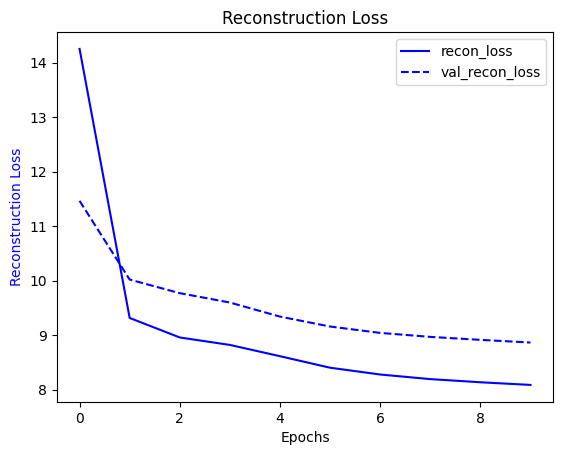

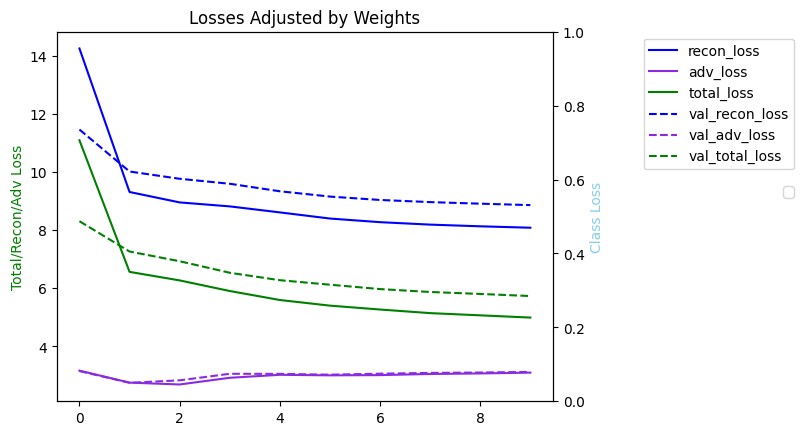

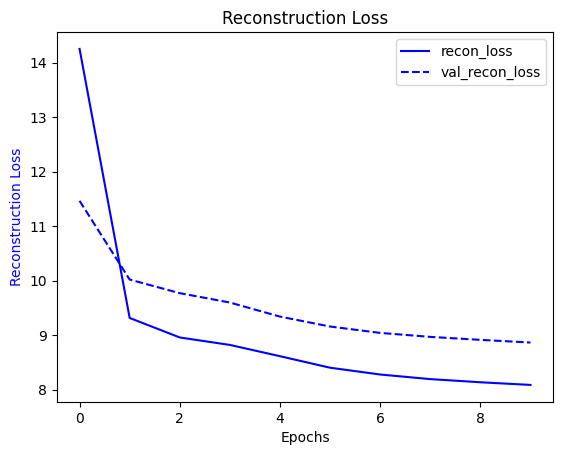

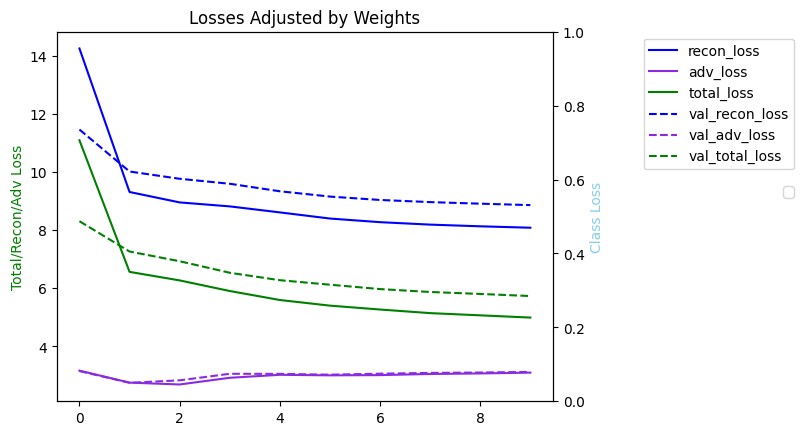

In [2]:
ae_aml = train_model_on_named_experiment("scmedalfe", "ASD", train_kwargs={"quick":True})

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits
Save model set to: True
Number of batches: 19
Ordered batches (donors): ['AML1012', 'AML210A', 'AML328', 'AML329', 'AML419A', 'AML420B', 'AML475', 'AML556', 'AML707B', 'AML870', 'AML916', 'AML921A', 'BM1', 'BM2', 'BM3', 'BM4', 'BM5', 'MUTZ3', 'OCI']


Running Fold 1


Created folder: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/saved_models/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28/splits_1
Created folder: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/figures/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.0_loss_la

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/val
X.shape before scaling (7684, 2916)
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/test


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


...

46/46 [==============================] - 2s 37ms/step - recon_loss: 0.5844 - la_clus_loss: 2.3522 - kld: 1.5479 - total_loss: 66.0713 - val_recon_loss: 0.4661 - val_la_clus_loss: 2.4036 - val_kld: 0.0000e+00 - val_total_loss: 51.5084
Epoch 8/10
44/46 [===========================>..] - ETA: 0s - recon_loss: 0.5597 - la_clus_loss: 2.2577 - kld: 1.5475 - total_loss: 63.3351WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 44ms/step - recon_loss: 0.5614 - la_clus_loss: 2.2493 - kld: 1.5475 - total_loss: 63.5293 - val_recon_loss: 0.4575 - val_la_clus_loss: 2.3136 - val_kld: 0.0000e+00 - val_total_loss: 50.5582
Epoch 9/10
45/46 [============================>.] - ETA: 0s - recon_loss: 0.5387 - la_clus_loss: 2.1799 - kld: 1.5471 - total_loss: 61.0254WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 35ms/step - recon_loss: 0.5408 - la_clus_loss: 2.1730 - kld: 1.5471 - total_loss: 61.2479 - val_recon_loss: 0.4502 - val_la_clus_loss: 2.2254 - val_kld: 0.0000e+00 - val_total_loss: 49.7392
Epoch 10/10
45/46 [============================>.] - ETA: 0s - recon_loss: 0.5198 - la_clus_loss: 2.1124 - kld: 1.5469 - total_loss: 58.9362WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 36ms/step - recon_loss: 0.5219 - la_clus_loss: 2.1108 - kld: 1.5469 - total_loss: 59.1725 - val_recon_loss: 0.4485 - val_la_clus_loss: 2.1452 - val_kld: 0.0000e+00 - val_total_loss: 49.5471
Thu Jul  3 17:29:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:03:00.0 Off |                    0 

<Figure size 640x480 with 0 Axes>

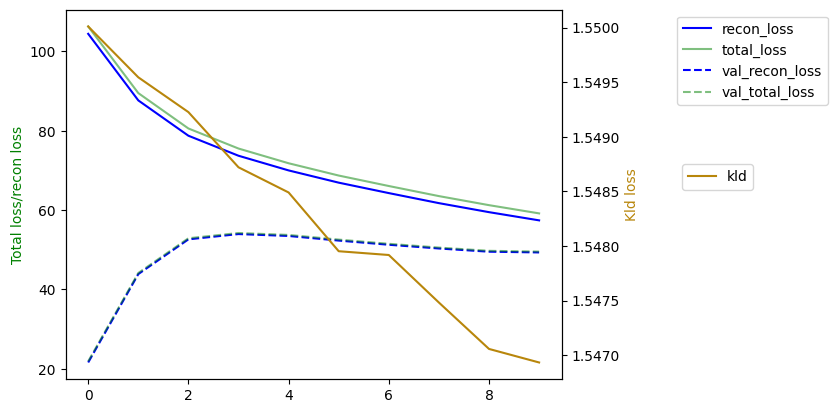

<Figure size 640x480 with 0 Axes>

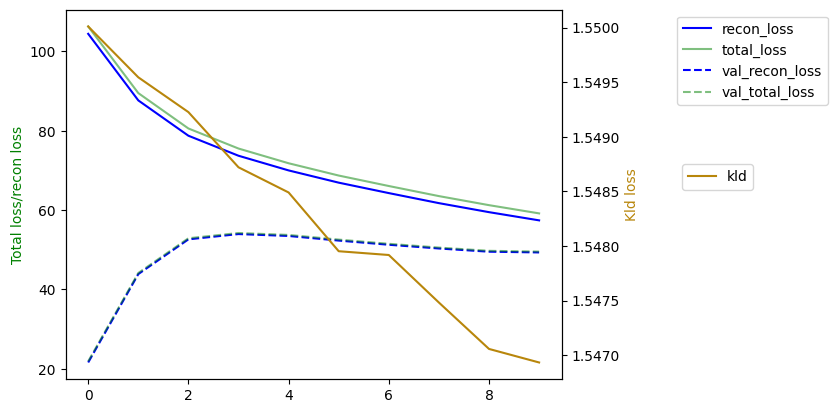

In [2]:
scmedalre_asd = train_model_on_named_experiment("scMEDAL-RE", "AML", model_kwargs={"n_latent_dims":50}, train_kwargs={"quick":True})

## Analyzing Models:

In [1]:
import analysis.analysis as aa

analysis_name = "AML_default"
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-03_17-56",
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_2025-06-26_20-03",
    "aec":"run_crossval_n_latent_dims-2_layer_units-512-132_n_pred-21_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_2025-06-26_20-21",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-42",
    "scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-53",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-2_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-27_10-17",
    #"scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28"
}
batches = ["AML420B", "BM5", "MUTZ3"]

aml_analysis = aa.AMLAnalysis(model_folder_dict, analysis_name)

2025-07-07 16:52:36.922573: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-07 16:52:37.024635: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-07 16:52:37.026199: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-07 16:52:40.043131: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
analysis_name = "ASD_default"
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-07_16-09",    
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42",
    #"scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-2_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-27_10-17",
}
batches =  ["donor_5531","donor_5945", "donor_5419", "donor_6032", "donor_5242",  "donor_5976", ]
asd = aa.ASDAnalysis(model_result_folder_dict=model_folder_dict, analysis_name=analysis_name,experiment_name= "ASD")

In [4]:
res= asd.clustering_scores(model_folder_dict)
res

Directory created or already exists: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes/ASD_default
ae /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/ae/run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-07_16-09
scmedalfe /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-07_16-42


Mean scores paths:
  sample_size       

In [3]:
gfd = asd.genomap(model_folder_dict, batches=batches, types=["train"], splits=[1], models=['scmedalfe'], cell_id_col="cell", celltype= ["L2/3"], num_iter=2)

Computing genomap for ['train'] [1] ['scmedalfe']
train 1 scmedalfe
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/ASD_data/reverse_norm/log_transformed_2916hvggenes/splits/split_1/train
batch_sel ['donor_5531', 'donor_5945', 'donor_5419', 'donor_6032', 'donor_5242', 'donor_5976']
Selected 1 cell from batch donor_5531 with celltype L2/3.
Selected 1 cell from batch donor_5945 with celltype L2/3.
Selected 1 cell from batch donor_5419 with celltype L2/3.
Selected 1 cell from batch donor_6032 with celltype L2/3.
Selected 1 cell from batch donor_5242 with celltype L2/3.
Selected 1 cell from batch donor_5976 with celltype L2/3.
Selected 294 additional cells from specified celltypes.
input_train
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/ASD_data/reverse_norm/log_transformed_2916hvggenes/splits/split_1/train
fe_ae_recon_train
recon_train
Shape of concatenated x

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Input does not contain NaNs
subset_input_z_scores shape: (900, 2916)


/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust layout to make room for colorbar


Missing indices: set()
Shape of std_across_batches: (54, 54)


/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:991: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


FileNotFoundError: [Errno 2] No such file or directory: '/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes/ASD_default/genomap_10topvariablegenesacrossbatches_CGTGTAACACTACAGT-1_5531_BA9_std_L2/3.png'

In [4]:
processors = asd.umap(model_folder_dict, types=["train"], splits=[2])
processors

TypeError: get_umap() argument after ** must be a mapping, not NoneType

In [ ]:


original_batch_list = []
for cell_id in cell_ids_2plot:
original_batch = obs_multibatch.loc[
    (obs_multibatch[cell_id_col] == cell_id)
    & (obs_multibatch["recon_prefix"] == f"recon_{Type}"),
    "batch",
].values[0]
original_batch_list.append(original_batch)

recon2plot = recon2plot + original_batch_list

plot_min = -1
plot_max = 2

for cell_id in cell_ids_2plot:
print("cell_id", cell_id)

original_batch = obs_multibatch.loc[
    (obs_multibatch[cell_id_col] == cell_id)
    & (obs_multibatch["recon_prefix"] == f"recon_{Type}"),
    "batch",
].values[0]
print("original batch:", original_batch)

original_celltype = obs_multibatch.loc[
    (obs_multibatch[cell_id_col] == cell_id)
    & (obs_multibatch["recon_prefix"] == f"recon_{Type}"),
    "celltype",
].values[0]
print("original batch:", original_celltype)

cell_indexes = obs_multibatch.loc[
    obs_multibatch[cell_id_col] == cell_id
].index.values
cell_indexes = cell_indexes.astype(int)
print("n cell indexes", cell_indexes)

cell_indexes_batch_cf = obs_multibatch.loc[
    (obs_multibatch[cell_id_col] == cell_id)
    & (obs_multibatch["batch"])#.str.contains("batch"))
    #& (obs_multibatch["recon_prefix"].str.contains("batch"))
].index.values
cell_indexes_batch_cf = cell_indexes_batch_cf.astype(int)
print("n cell indexes for batch CF recon", cell_indexes_batch_cf)
print("obs_multibatch['recon_prefix']", obs_multibatch["recon_prefix"].values)

genomap_coordinates = compute_cell_stats_acrossbatchrecon(
    genomap,
    cell_indexes_batch_cf,
    genomap_coordinates,
    statistic=statistic,
    n_top_genes=10,
    order="C",
    path_2_genomap=path_2_genomap,
    file_name=cell_id,
)

print(genomap_coordinates[genomap_coordinates["Top_N"]])
plot_cell_recon_genomap(
    genomap,
    cell_indexes,
    genomap_coordinates,
    obs=obs_multibatch,
    original_batch=original_batch,
    n_top_genes=10,
    min_val=plot_min,
    max_val=plot_max,
    order="C",
    path_2_genomap=path_2_genomap,
    file_name=f"{cell_id}_{statistic}_{original_celltype}",
)

cell_indexes_few_batches = obs_multibatch.loc[
    (obs_multibatch[cell_id_col] == cell_id)
    & obs_multibatch["recon_prefix"].apply(
        lambda x: any(recon in x for recon in recon2plot)
    )
].index.values
# No gene labels
try:
    plot_cell_recon_genomap(
        genomap,
        cell_indexes=cell_indexes_few_batches,
        genomap_coordinates=None,
        obs=obs_multibatch,
        original_batch=original_batch,
        n_top_genes=10,
        min_val=plot_min,
        max_val=plot_max,
        n_cols=n_batch_cols2plot + n_inputs_fe,
        order="C",
        path_2_genomap=path_2_genomap,
        file_name=f"{cell_id}_few_batches_{statistic}_{original_celltype}",
        remove_ticks=True,
    )
except Exception as e: 
    raise e   

In [5]:
(genomap, cell_indexes_few_batches, obs_multibatch, original_batch, plot_min, plot_max,
  n_cols, path_2_genomap) = gfd
cell_ids_2plot= ['AML420B-D35_TGCATGGCTTGN', 'AML420B-D35_TTATTATTCTAA', 'MUTZ3_TGCGGCCAGAGA']

original_batch

'AML420B'

In [6]:
from utils.genomaps_utils import plot_cell_recon_genomap
plot_cell_recon_genomap(
    genomap,
    cell_indexes=cell_indexes_few_batches,
    genomap_coordinates=None,
    obs=obs_multibatch,
    min_val=plot_min, 
    max_val=plot_max,
    n_cols=10,
    order="C",
    path_2_genomap=path_2_genomap,
    file_name="asdfasdfasdf",
    remove_ticks=True
)

ValueError: Number of rows must be a positive integer, not 0